In [1]:
#IMPORT NEEDED LIBRARIES
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
#CREATE MODEL AS CLASS
class Model(nn.Module):
    #Input layer (8 features)
    #Hidden layer 1 (10 neurons)
    #H2(12), H3(12), H4(12)
    #Output (1 target)

    def __init__(self, in_features = 7, h1 = 12, h2 =12, h3 = 12, h4 = 12, out_features = 1):
        super().__init__() #Instantiate our nn.Module

        self.fc1 = nn.Linear(in_features, h1) #fully connecter(starting, moving to)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, h3)
        self.fc4 = nn.Linear(h3, h4)
        self.out = nn.Linear(h4, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x)) #Rectived Linear Unit, output less than 0 is cero
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = self.out(x)

        return x

In [4]:
#GENERATE RANDOM SEED
torch.manual_seed(66)

In [5]:
#CREATE INSTANCE OF MODEL
model = Model()

In [6]:
#LOAD DATA
file_route = 'Final_Table.csv'
df = pd.read_csv(file_route)

df.head() #BIEN

,DATE,DAY,WEEK_DAY,MONTH,YEAR,HOLIDAY,PRE_HOLIDAY,LAST_WEEK_TOTAL,TOTAL
0,9/1/2025,1,2,9,2025,0,0,24689.32480,2741.0
1,9/2/2025,2,3,9,2025,0,0,24676.15920,2891.0
2,9/3/2025,3,4,9,2025,0,0,24632.38930,2557.0
3,9/4/2025,4,5,9,2025,0,0,24694.46564,3163.0
4,9/5/2025,5,6,9,2025,0,0,24736.15743,3453.0


In [7]:
#CONVERT TO NUMERICAL VALUE
# Normalize LAST_WEEK_TOTAL
from sklearn.preprocessing import StandardScaler
scaler_ventas = StandardScaler()
df["LAST_WEEK_TOTAL"] = scaler_ventas.fit_transform(df[["LAST_WEEK_TOTAL"]])
#df["LAST_WEEK_TOTAL"]  = df["LAST_WEEK_TOTAL"]/1000


df["YEAR"]  = df["YEAR"]/1000
df["TOTAL"]  = df["TOTAL"]/1000
df["DAY"] = df["DAY"]/30


In [8]:
#SPLIT X, y
X = df[["DAY", "WEEK_DAY", "MONTH", "YEAR", "HOLIDAY", "PRE_HOLIDAY", "LAST_WEEK_TOTAL"]]
y = df['TOTAL']

In [9]:
#Convert to numpy arrays
X = X.values
y = y.values

In [10]:
#X

In [11]:
#TRAIN AND TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 66)

In [12]:
#CONVERT X, y FEATURES TO LONG TENSORS
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

y_train = y_train.view(-1, 1)
y_test  = y_test.view(-1, 1)


In [13]:
#CRITERIAN TO MEASURE ERROR, how off prediction is
criterion = nn.MSELoss()

#ADAM OPTIMIZER, lr=Learning Rate (if error doesnt go down after bunch of iterations(epochs), lower lr)
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-2)

In [14]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=7, out_features=12, bias=True)
  (fc2): Linear(in_features=12, out_features=12, bias=True)
  (fc3): Linear(in_features=12, out_features=12, bias=True)
  (fc4): Linear(in_features=12, out_features=12, bias=True)
  (out): Linear(in_features=12, out_features=1, bias=True)
)>

In [15]:
#Train or model!

#Epochs? (1 run thru all trainig data)
epochs = 8000
losses = []

for i in range(epochs):
    #Go forward and get a prediction
    ##y_predict = model.forward(X_train) #Get predicted results
    y_predict = model(X_train)
    #Measure the loss/error, gonna be high at first
    loss = criterion(y_predict, y_train) #Predicted values vs the y_train

    #Keep Track of our losses
    losses.append(loss.detach().numpy())

    #Print every 10 epochs
    if i % 100 == 0:
        print(f"Epoch: {i} and loss: {loss}")
    #Do some back propagation: take the error rate of forward propagation and feed it back thru the network to fine tune the weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch: 0 and loss: 18.471593856811523
Epoch: 100 and loss: 0.6283928155899048
Epoch: 200 and loss: 0.5141739249229431
Epoch: 300 and loss: 0.4814179241657257
Epoch: 400 and loss: 0.4682285487651825
Epoch: 500 and loss: 0.4476569592952728
Epoch: 600 and loss: 0.38305988907814026
Epoch: 700 and loss: 0.3605894446372986
Epoch: 800 and loss: 0.34527266025543213
Epoch: 900 and loss: 0.32976657152175903
Epoch: 1000 and loss: 0.3115706145763397
Epoch: 1100 and loss: 0.29991328716278076
Epoch: 1200 and loss: 0.2889857590198517
Epoch: 1300 and loss: 0.2913154065608978
Epoch: 1400 and loss: 0.3102707266807556
Epoch: 1500 and loss: 0.261993944644928
Epoch: 1600 and loss: 0.2574746310710907
Epoch: 1700 and loss: 0.2590620517730713
Epoch: 1800 and loss: 0.2656961977481842
Epoch: 1900 and loss: 0.24946631491184235
Epoch: 2000 and loss: 0.2585177421569824
Epoch: 2100 and loss: 0.23990540206432343
Epoch: 2200 and loss: 0.24163617193698883
Epoch: 2300 and loss: 0.23628124594688416
Epoch: 2400 and loss:

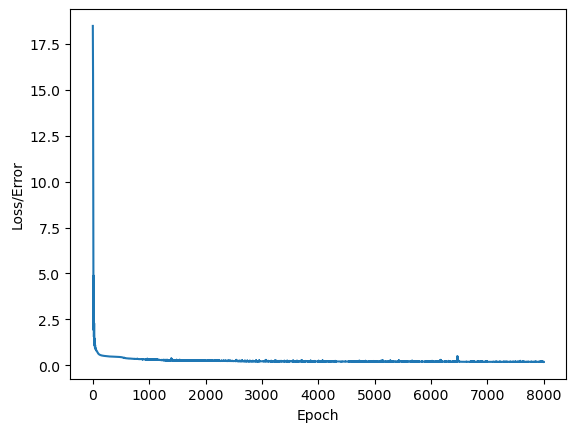

In [16]:
#Graph it out!
plt.plot(range(epochs), losses)
plt.ylabel("Loss/Error")
plt.xlabel("Epoch")
plt.show()

In [17]:
#Evaluate Moodel on Test Data Set (validate model on test set)
with torch.no_grad() : #Bascally turn off the back propagation
    y_eval = model.forward(X_test) #X_test are features from our test set, y_eval will be predictions
    loss = criterion(y_eval, y_test) #Find the loss/error

In [18]:
loss

tensor(0.8780)

In [19]:
predict_test = pd.DataFrame({'DAY': [26,27,28,29,30,31,1],
                            'WEEK_DAY': [2,3,4,5,6,7,1],
                            'MONTH': [1,1,1,1,1,1,2],
                            'YEAR': [2026, 2026, 2026, 2026, 2026, 2026, 2026],
                            'HOLIDAY': [0,0,0,0,0,0,0],
                            'PRE_HOLIDAY': [0,0,0,0,0,0,0],
                            'LAST_WEEK_TOTAL': [30940,30210,30800,31130,30000,32950,32872]})

predict_test["YEAR"] = predict_test["YEAR"]/1000
predict_test["DAY"] = predict_test["DAY"]/30

# Normalize LAST_WEEK_TOTAL
predict_test["LAST_WEEK_TOTAL"] = scaler_ventas.fit_transform(predict_test[["LAST_WEEK_TOTAL"]])
#predict_test["LAST_WEEK_TOTAL"] = predict_test["LAST_WEEK_TOTAL"]/1000

predict_test

,DAY,WEEK_DAY,MONTH,YEAR,HOLIDAY,PRE_HOLIDAY,LAST_WEEK_TOTAL
0,0.866667,2,1,2.026,0,0,-0.301475
1,0.900000,3,1,2.026,0,0,-0.964928
2,0.933333,4,1,2.026,0,0,-0.428713
3,0.966667,5,1,2.026,0,0,-0.128796
4,1.000000,6,1,2.026,0,0,-1.155784
5,1.033333,7,1,2.026,0,0,1.525293
6,0.033333,1,2,2.026,0,0,1.454403


In [20]:
predict_test = predict_test.values

In [21]:
predict_test = torch.FloatTensor(predict_test)

In [22]:
predict_test

tensor([[ 0.8667,  2.0000,  1.0000,  2.0260,  0.0000,  0.0000, -0.3015],
        [ 0.9000,  3.0000,  1.0000,  2.0260,  0.0000,  0.0000, -0.9649],
        [ 0.9333,  4.0000,  1.0000,  2.0260,  0.0000,  0.0000, -0.4287],
        [ 0.9667,  5.0000,  1.0000,  2.0260,  0.0000,  0.0000, -0.1288],
        [ 1.0000,  6.0000,  1.0000,  2.0260,  0.0000,  0.0000, -1.1558],
        [ 1.0333,  7.0000,  1.0000,  2.0260,  0.0000,  0.0000,  1.5253],
        [ 0.0333,  1.0000,  2.0000,  2.0260,  0.0000,  0.0000,  1.4544]])

In [23]:
evaluation = model.forward(predict_test)

In [24]:
evaluation

tensor([[3.7122],
        [3.7892],
        [4.0228],
        [4.1724],
        [4.3806],
        [5.4673],
        [3.5863]], grad_fn=<AddmmBackward0>)